In [ ]:
# Colab cell 1 - check GPU and basic python info
import torch, sys
print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [ ]:
# Colab cell 2 - install packages
!pip install -q torch torchvision torchaudio --upgrade
!pip install -q numpy pandas matplotlib tqdm scikit-learn pillow opencv-python
# Optional (uncomment if you want advanced augmentation)
# !pip install -q albumentations
# Kaggle client to download dataset (optional)
!pip install -q kaggle


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 771.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17

In [ ]:
# Colab cell 3 - mount Google Drive (optional)
from google.colab import drive
drive.mount('/content/drive')
# Example: create a project folder in your drive
!mkdir -p /content/drive/MyDrive/brain_mri_project


Mounted at /content/drive


In [ ]:
!ls


brain-tumor-dataset.zip  drive	sample_data


In [ ]:
!file brain-tumor-dataset.zip


brain-tumor-dataset.zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [ ]:
!ls -lh brain-tumor-dataset.zip


-rw-r--r-- 1 root root 149M Dec  9 16:32 brain-tumor-dataset.zip


In [ ]:
!unzip -o brain-tumor-dataset.zip -d brain_tumor_dataset


Streaming output truncated to the last 5000 lines.
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0712.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0713.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0714.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0715.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0716.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0717.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0718.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0719.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0720.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0721.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0722.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0723.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0724.jpg  
  inflating: brain_tumor_dataset/Training/glioma/Tr-gl_0725.jpg  
  inflating: brain_tumor_

In [ ]:
!ls

brain_tumor_dataset  brain-tumor-dataset.zip  drive  sample_data


In [ ]:
!rm -rf /content/brain_mri   # remove old folder if exists
!unzip -q /content/brain-tumor-dataset.zip -d /content/brain_mri


In [ ]:
import os

print("MAIN FOLDERS:", os.listdir('/content/brain_mri'))

print("\nTraining:", os.listdir('/content/brain_mri/Training'))
print("Testing:", os.listdir('/content/brain_mri/Testing'))


MAIN FOLDERS: ['Training', 'Testing']

Training: ['notumor', 'meningioma', 'glioma', 'pituitary']
Testing: ['notumor', 'meningioma', 'glioma', 'pituitary']


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
IMAGE_SIZE = 224   # Standard input for ResNet/DenseNet/EfficientNet
BATCH_SIZE = 32


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# EDA

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

img_path = "/content/brain_mri/Training/meningioma/Tr-me_0011.jpg"

img = Image.open(img_path)

plt.imshow(img, cmap="gray")
plt.title("Sample: Meningioma MRI")
plt.axis("off")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/brain_mri/Training/meningioma/Tr-me_0011.jpg'

In [ ]:
import os, random
from PIL import Image
import matplotlib.pyplot as plt

cls = "meningioma"
folder = f"/content/brain_mri/Training/{cls}"

img_name = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_name)

img = Image.open(img_path)

plt.imshow(img, cmap="gray")
plt.title(f"Random {cls} MRI")
plt.axis("off")
plt.show()

print("Loaded image:", img_name)


In [ ]:
TRAIN_DIR = "/content/brain_mri/Training"
TEST_DIR  = "/content/brain_mri/Testing"


In [ ]:
def count_images(folder):
    class_counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len(os.listdir(cls_path))
    return class_counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print("Training counts:", train_counts)
print("Testing counts:", test_counts)


In [ ]:
def count_images(folder):
    class_counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len(os.listdir(cls_path))
    return class_counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print("Training counts:", train_counts)
print("Testing counts:", test_counts)


In [ ]:
def plot_distribution(counts, title):
    classes = list(counts.keys())
    values = list(counts.values())

    colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta']

    plt.figure(figsize=(7,4))
    plt.bar(classes, values, color=colors[:len(classes)])
    plt.title(title)
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.show()

plot_distribution(train_counts, "Training Set Class Distribution")
plot_distribution(test_counts,  "Testing Set Class Distribution")


In [ ]:
import random

def show_random_images(folder, n=4):
    plt.figure(figsize=(12, 8))

    classes = sorted(os.listdir(folder))

    for idx, cls in enumerate(classes):
        cls_folder = os.path.join(folder, cls)
        img_name = random.choice(os.listdir(cls_folder))
        img_path = os.path.join(cls_folder, img_name)

        img = Image.open(img_path)

        plt.subplot(len(classes), n, idx*n + 1)
        plt.imshow(img, cmap='gray')
        plt.title(cls)
        plt.axis("off")

show_random_images(TRAIN_DIR, n=3)


In [ ]:
def get_avg_size(folder):
    widths, heights = [], []

    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            for img_name in os.listdir(cls_path):
                img_path = os.path.join(cls_path, img_name)
                try:
                    img = Image.open(img_path)
                    widths.append(img.size[0])
                    heights.append(img.size[1])
                except:
                    pass

    return np.mean(widths), np.mean(heights)

avg_w, avg_h = get_avg_size(TRAIN_DIR)
print(f"Average image size: {avg_w:.2f} x {avg_h:.2f}")


In [ ]:
def check_corrupted(folder):
    corrupted = []
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            try:
                Image.open(img_path).verify()
            except Exception as e:
                corrupted.append(img_path)
    return corrupted

bad_train = check_corrupted(TRAIN_DIR)
bad_test = check_corrupted(TEST_DIR)

print("Corrupted train images:", bad_train)
print("Corrupted test images:", bad_test)


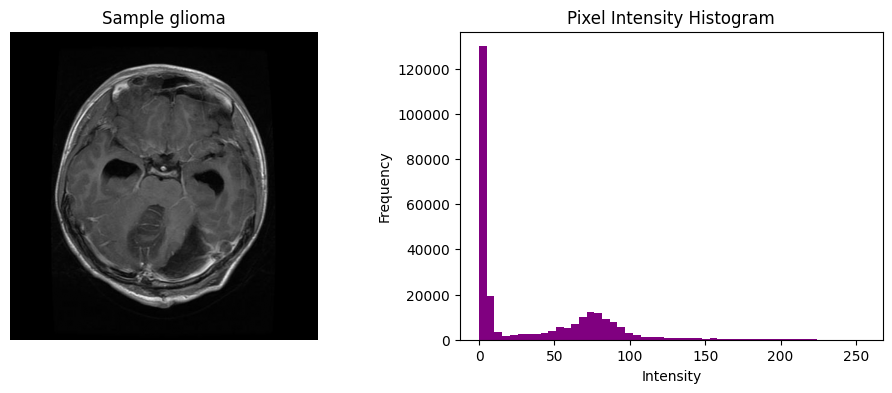

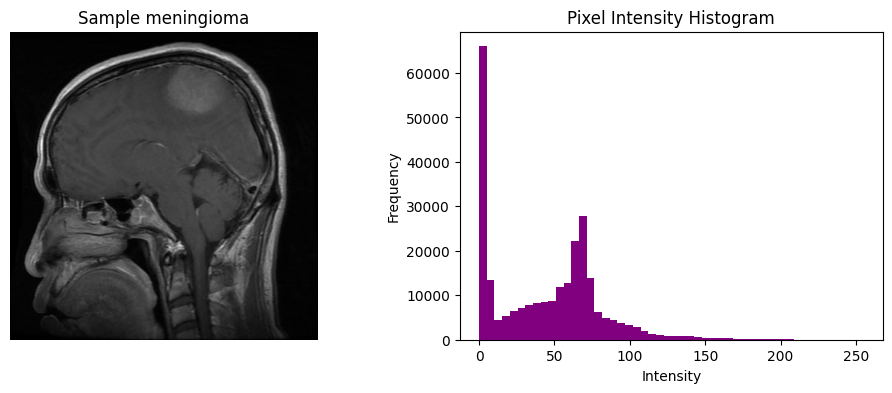

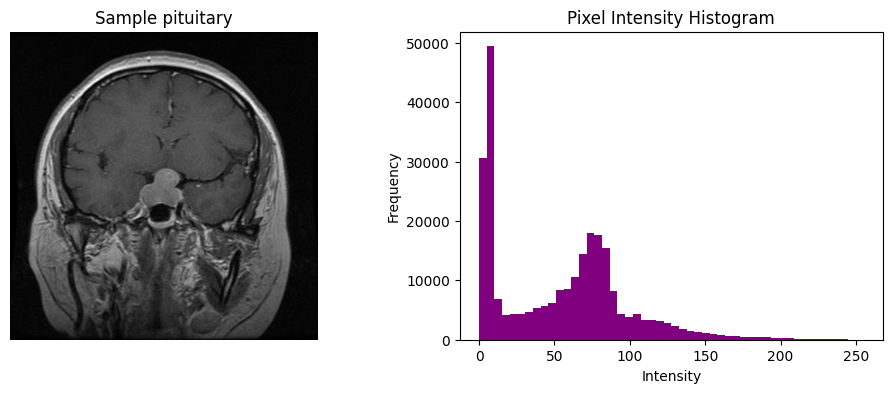

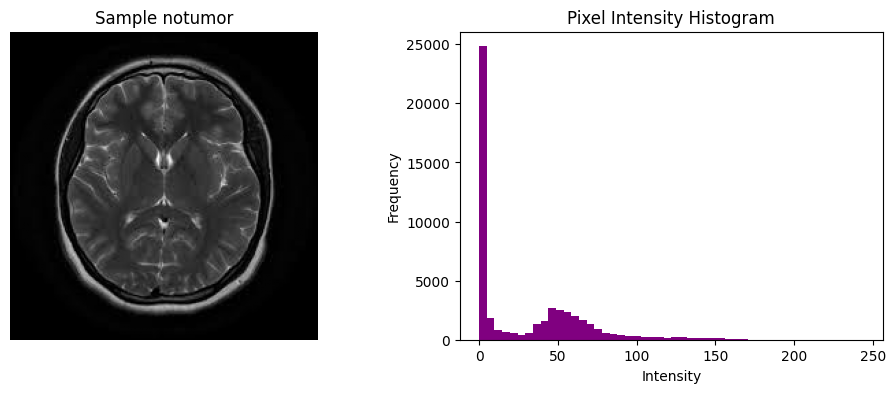

In [ ]:
import cv2

def plot_histogram(folder, cls):
    cls_folder = os.path.join(folder, cls)
    img_name = random.choice(os.listdir(cls_folder))
    img_path = os.path.join(cls_folder, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Sample {cls}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.hist(img.ravel(), bins=50, color='purple')
    plt.title("Pixel Intensity Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.show()

plot_histogram(TRAIN_DIR, "glioma")
plot_histogram(TRAIN_DIR, "meningioma")
plot_histogram(TRAIN_DIR, "pituitary")
plot_histogram(TRAIN_DIR, "notumor")



In [ ]:
TRAIN_DIR = "/content/brain_mri/Training"
TEST_DIR  = "/content/brain_mri/Testing"

classes = sorted(os.listdir(TRAIN_DIR))
print("Classes:", classes)


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


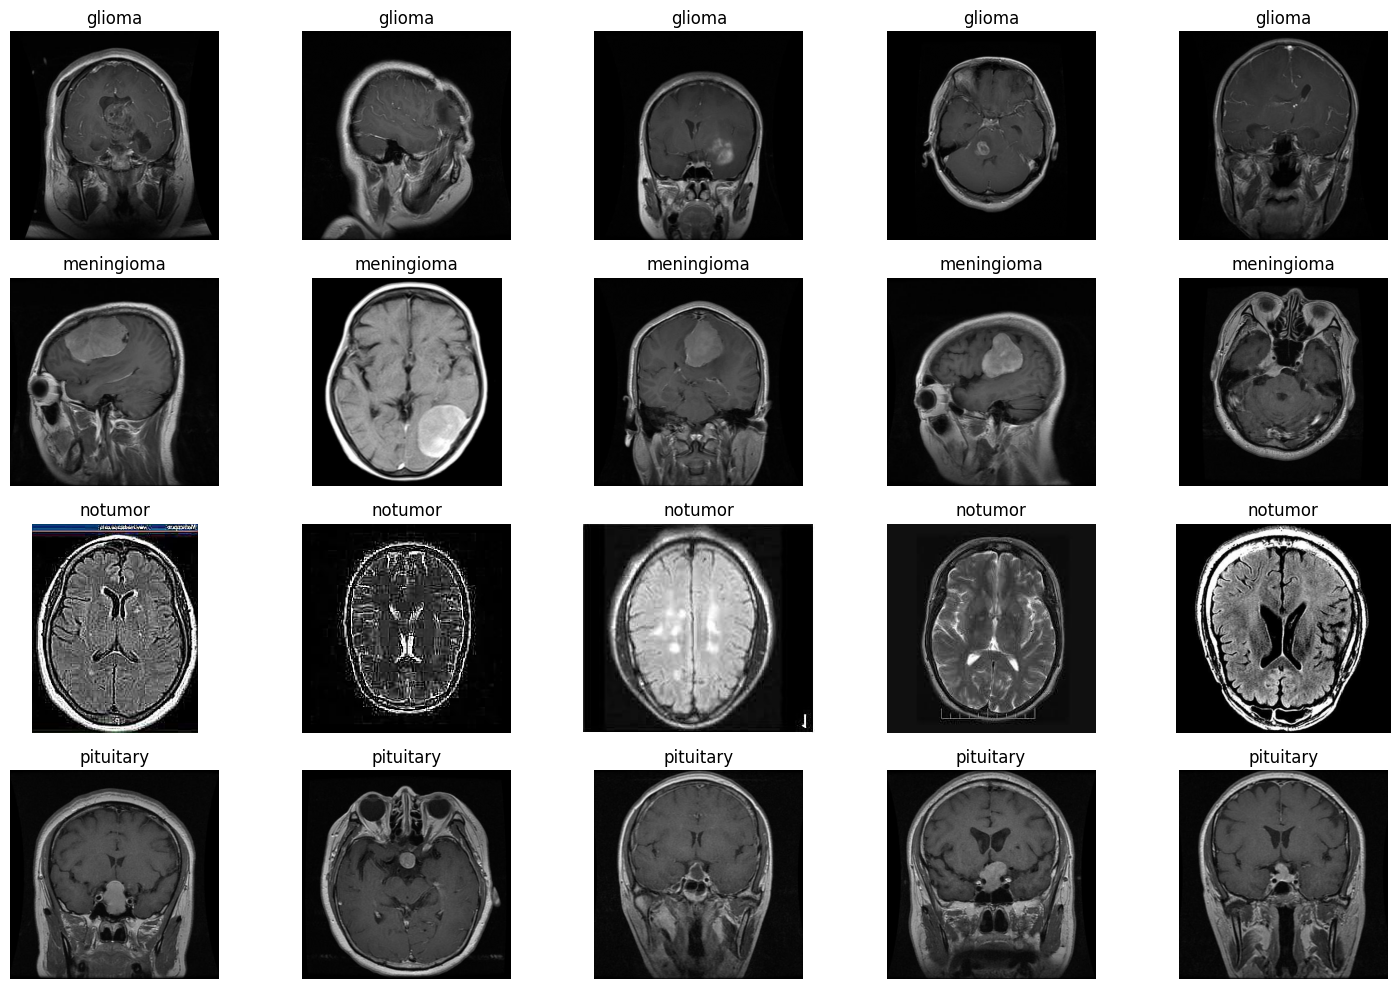

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import random

def visualize_class_samples(folder, classes, n_per_class=5):
    plt.figure(figsize=(15, 10))
    i = 1

    for cls in classes:
        cls_path = os.path.join(folder, cls)
        images = os.listdir(cls_path)
        random.shuffle(images)

        for img_name in images[:n_per_class]:
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)

            plt.subplot(len(classes), n_per_class, i)
            plt.imshow(img, cmap='gray')
            plt.title(cls)
            plt.axis("off")
            i += 1

    plt.tight_layout()
    plt.show()

visualize_class_samples(TRAIN_DIR, classes, n_per_class=5)


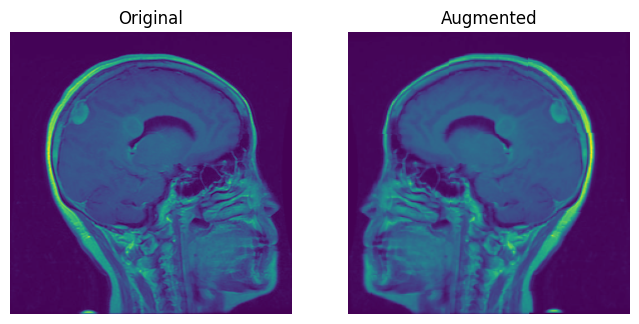

In [ ]:
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

augment = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
])

to_tensor = transforms.ToTensor()

img_path = TRAIN_DIR + "/glioma/" + random.choice(os.listdir(TRAIN_DIR + "/glioma"))
img = Image.open(img_path)

augmented = augment(img)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(augmented)
plt.title("Augmented")
plt.axis("off")

plt.show()


In [ ]:
import numpy as np

def avg_brightness(folder):
    values = []
    for img_name in os.listdir(folder):
        img = np.array(Image.open(os.path.join(folder, img_name)).convert("L"))
        values.append(img.mean())
    return np.mean(values)

for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    print(f"{cls} average brightness:", avg_brightness(cls_path))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def average_image(folder):
    imgs = []
    for img_name in os.listdir(folder)[:200]:  # limit to speed up
        img = Image.open(os.path.join(folder, img_name)).convert("L").resize((224,224))
        imgs.append(np.array(img))
    return np.mean(imgs, axis=0)

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    avg_img = average_image(os.path.join(TRAIN_DIR, cls))

    plt.subplot(2,2,i+1)
    plt.imshow(avg_img, cmap="viridis")
    plt.title(f"Average of {cls}")
    plt.axis("off")

plt.show()


In [ ]:
import seaborn as sns

widths = []
heights = []

for cls in classes:
    folder = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(folder):
        img = Image.open(os.path.join(folder, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

sns.histplot(widths, kde=True)
plt.title("Image Width Distribution")
plt.show()

sns.histplot(heights, kde=True)
plt.title("Image Height Distribution")
plt.show()


In [ ]:
import cv2
import matplotlib.pyplot as plt

def plot_intensity(folder, cls):
    path = os.path.join(folder, cls)
    img_name = random.choice(os.listdir(path))
    img = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.hist(img.ravel(), bins=50, color='blue')
    plt.title("Intensity Histogram")
    plt.show()

for cls in classes:
    plot_intensity(TRAIN_DIR, cls)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))

for i, cls in enumerate(classes):
    folder = os.path.join(TRAIN_DIR, cls)
    img_name = random.choice(os.listdir(folder))
    img = Image.open(os.path.join(folder, img_name))

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os, random

img_path = "/content/brain_mri/Training/glioma/" + random.choice(os.listdir("/content/brain_mri/Training/glioma"))
img = Image.open(img_path).convert("L")  # convert to grayscale
img_np = np.array(img)

plt.figure(figsize=(8,4))

plt.hist(img_np.flatten(), bins=256, color='black')
plt.title("Grayscale Intensity Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os, random

folder = "/content/brain_mri/Training/glioma"
img = Image.open(os.path.join(folder, random.choice(os.listdir(folder))))

img_np = np.array(img)

plt.figure(figsize=(8,4))

# If image is RGB (H,W,3)
if len(img_np.shape) == 3:
    colors = ('r','g','b')
    for i, col in enumerate(colors):
        hist = np.histogram(img_np[:,:,i].flatten(), bins=256, range=(0,256))[0]
        plt.plot(hist, color=col)
    plt.title("RGB Channel Histogram")

# If image is grayscale (H,W)
else:
    plt.hist(img_np.flatten(), bins=256, color='black')
    plt.title("Grayscale Histogram")

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os, random

folder = "/content/brain_mri/Training/meningioma"
img_path = os.path.join(folder, random.choice(os.listdir(folder)))
img = Image.open(img_path).convert("L")
img_np = np.array(img)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.hist(img_np.flatten(), bins=256, color='black')
plt.title("Pixel Intensity Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.show()


In [ ]:
import os

TRAIN_DIR = "/content/brain_mri/Training"
TEST_DIR  = "/content/brain_mri/Testing"

def count_images(path):
    class_counts = {}
    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len(os.listdir(cls_path))
    return class_counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print("📌 Training Set Image Counts:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\n📌 Testing Set Image Counts:")
for cls, count in test_counts.items():
    print(f"{cls}: {count}")


In [ ]:
import matplotlib.pyplot as plt

def plot_counts(counts, title):
    classes = list(counts.keys())
    values = list(counts.values())

    plt.figure(figsize=(7,4))
    plt.bar(classes, values, color="skyblue")
    plt.title(title)
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.show()

plot_counts(train_counts, "Training Set Class Distribution")
plot_counts(test_counts,  "Testing Set Class Distribution")


# Models implementation

# CNN from SCRATCH

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device


In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112x112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56x56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28x28

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 14x14

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

baseline_model = BaselineCNN(num_classes=4).to(device)
baseline_model


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)


In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100 * correct / total


def validate(model, loader):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100 * correct / total


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

TRAIN_DIR = "/content/brain_mri/Training"
TEST_DIR  = "/content/brain_mri/Testing"

full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)

# 85% train, 15% validation
val_size = int(0.15 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

val_dataset.dataset.transform = test_transform

test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

classes = full_train_dataset.classes

print("Classes:", classes)
print("Train:", len(train_loader.dataset))
print("Val:", len(val_loader.dataset))
print("Test:", len(test_loader.dataset))


In [ ]:
EPOCHS = 10

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch(baseline_model, train_loader, optimizer)
    val_loss, val_acc = validate(baseline_model, val_loader)

    print(f"Epoch {epoch}:")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.2f}%")


# MODEL 1: ResNet50 (Transfer Learning)

In [ ]:
from torchvision import models
import torch.nn as nn

# Load pretrained ResNet50
resnet50 = models.resnet50(weights="IMAGENET1K_V2")

# Freeze feature extractor
for param in resnet50.parameters():
    param.requires_grad = False

# Replace final layer (fc)
num_features = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_features, 4)  # 4 classes

resnet50 = resnet50.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(resnet50.fc.parameters(), lr=0.0005)

resnet50


In [ ]:
EPOCHS = 5

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch(resnet50, train_loader, optimizer_resnet)
    val_loss, val_acc = validate(resnet50, val_loader)

    print(f"\nResNet50 | Epoch {epoch}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f},   Val Acc: {val_acc:.2f}%")


# MODEL 3: EfficientNet-B0

In [ ]:
effnet = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Freeze base layers
for param in effnet.parameters():
    param.requires_grad = False

# Replace classifier (EfficientNet-B0 uses classifier[1])
num_features = effnet.classifier[1].in_features
effnet.classifier[1] = nn.Linear(num_features, 4)

effnet = effnet.to(device)

optimizer_effnet = torch.optim.Adam(effnet.classifier.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()


In [ ]:
EPOCHS = 5

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch(effnet, train_loader, optimizer_effnet)
    val_loss, val_acc = validate(effnet, val_loader)

    print(f"\nEfficientNet-B0 | Epoch {epoch}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f},   Val Acc: {val_acc:.2f}%")


# MobileNetV2

In [ ]:
mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V1")
for param in mobilenet.features.parameters():
    param.requires_grad = False

mobilenet.classifier[1] = nn.Linear(mobilenet.classifier[1].in_features, 4)
mobilenet = mobilenet.to(device)


# VGG16

In [ ]:
vgg16 = models.vgg16(weights="IMAGENET1K_V1")
for param in vgg16.features.parameters():
    param.requires_grad = False

vgg16.classifier[6] = nn.Linear(4096, 4)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
def evaluate_model(model, loader):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = outputs.max(1)
            preds.extend(predicted.cpu().numpy())
            trues.extend(labels.cpu().numpy())

    acc = accuracy_score(trues, preds)
    return acc, trues, preds


In [ ]:
def plot_conf_matrix(trues, preds, classes, model_name):
    cm = confusion_matrix(trues, preds)

    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [ ]:
def show_classification_report(trues, preds, classes, model_name):
    print(f"\nClassification Report - {model_name}")
    print(classification_report(trues, preds, target_names=classes))


In [ ]:
from torchvision import models
import torch.nn as nn

# Load pretrained DenseNet121
densenet = models.densenet121(weights="IMAGENET1K_V1")

# Freeze feature extractor
for param in densenet.parameters():
    param.requires_grad = False

# Replace classifier for 4 classes
num_features = densenet.classifier.in_features
densenet.classifier = nn.Linear(num_features, 4)

densenet = densenet.to(device)

# Optimizer
optimizer_dense = torch.optim.Adam(densenet.classifier.parameters(), lr=0.0005)

print("DenseNet121 is ready!")


In [ ]:
EPOCHS = 5

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch(densenet, train_loader, optimizer_dense)
    val_loss, val_acc = validate(densenet, val_loader)

    print(f"\nDenseNet121 | Epoch {epoch}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f},   Val Acc: {val_acc:.2f}%")


In [ ]:
# Ensure device is set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move all models to GPU/CPU
baseline_model = baseline_model.to(device)
resnet50       = resnet50.to(device)
densenet       = densenet.to(device)
effnet         = effnet.to(device)
mobilenet      = mobilenet.to(device)
vgg16          = vgg16.to(device)

print("All models moved to device successfully!")


In [ ]:
def evaluate_model(model, loader):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)  # <-- match device
            outputs = model(images)

            _, predicted = outputs.max(1)
            preds.extend(predicted.cpu().numpy())
            trues.extend(labels.cpu().numpy())

    acc = accuracy_score(trues, preds)
    return acc, trues, preds


In [ ]:
models = {
    "Baseline CNN": baseline_model,
    "ResNet50": resnet50,
    "DenseNet121": densenet,
    "EfficientNetB0": effnet,
    "MobileNetV2": mobilenet,
    "VGG16": vgg16
}

results = {}
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

for name, model in models.items():
    print(f"\n----- Evaluating {name} -----")

    acc, trues, preds = evaluate_model(model, test_loader)
    results[name] = acc * 100

    print(f"Test Accuracy: {acc*100:.2f}%")

    show_classification_report(trues, preds, classes, name)
    plot_conf_matrix(trues, preds, classes, name)


In [ ]:
def show_classification_report(trues, preds, classes, model_name):
    print(f"\n===== Classification Report: {model_name} =====")
    print(classification_report(trues, preds, target_names=classes))


In [ ]:
def top_k_accuracy(model, loader, k=3):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, topk = outputs.topk(k, dim=1)

            correct += (topk == labels.view(-1,1)).sum().item()
            total += labels.size(0)

    return correct / total


In [ ]:
models = {
    "Baseline CNN": baseline_model,
    "ResNet50": resnet50,
    "DenseNet121": densenet,
    "EfficientNetB0": effnet,
    "MobileNetV2": mobilenet,
    "VGG16": vgg16
}

results = {}

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

for name, model in models.items():
    print(f"\n====================")
    print(f" Evaluating {name}")
    print(f"====================")

    acc, trues, preds = evaluate_model(model, test_loader)
    results[name] = acc * 100

    print(f"\n✔ Test Accuracy: {acc*100:.2f}%")

    show_classification_report(trues, preds, classes, name)
    plot_conf_matrix(trues, preds, classes, name)

    top3 = top_k_accuracy(model, test_loader, k=3)
    print(f"✔ Top-3 Accuracy: {top3*100:.2f}%")


In [ ]:
plt.figure(figsize=(10,5))
names = list(results.keys())
acc_values = list(results.values())

plt.bar(names, acc_values, color='skyblue')
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison: Test Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(axis='y')
plt.show()


In [ ]:
print("\n====== Final Model Performance Summary ======\n")
for name, acc in results.items():
    print(f"{name:20s} : {acc:.2f}%")


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

metrics = {}

for name, model in models.items():
    acc, trues, preds = evaluate_model(model, test_loader)

    precision, recall, f1, _ = precision_recall_fscore_support(
        trues, preds, average='macro'
    )

    metrics[name] = {
        "accuracy": acc * 100,
        "precision": precision * 100,
        "recall": recall * 100,
        "f1": f1 * 100
    }

metrics


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models_list = list(metrics.keys())
accuracy = [metrics[m]["accuracy"] for m in models_list]
precision = [metrics[m]["precision"] for m in models_list]
recall = [metrics[m]["recall"] for m in models_list]
f1 = [metrics[m]["f1"] for m in models_list]

x = np.arange(len(models_list))
w = 0.2

plt.figure(figsize=(12,6))
plt.bar(x - w, accuracy, width=w, label='Accuracy')
plt.bar(x, precision, width=w, label='Precision')
plt.bar(x + w, recall, width=w, label='Recall')
plt.bar(x + 2*w, f1, width=w, label='F1-score')

plt.xticks(x, models_list, rotation=45)
plt.ylabel("Score (%)")
plt.title("Model Comparison: Accuracy, Precision, Recall, F1")
plt.legend()
plt.grid(axis="y")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
num_vars = len(labels)

plt.figure(figsize=(10,10))

for model_name in metrics.keys():
    values = [
        metrics[model_name]["accuracy"],
        metrics[model_name]["precision"],
        metrics[model_name]["recall"],
        metrics[model_name]["f1"]
    ]
    angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]

    plt.polar(angles, values, marker='o', label=model_name)

plt.title("Performance Comparison: Radar Plot")
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,12))

axes = axes.flatten()

i = 0
for name, model in models.items():
    acc, trues, preds = evaluate_model(model, test_loader)
    cm = confusion_matrix(trues, preds)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=axes[i])

    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    i += 1

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10,5))
plt.plot(models_list, accuracy, marker='o')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [ ]:
def train_model(model, optimizer, train_loader, val_loader, epochs=10):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        # ----- TRAIN -----
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # ----- VALIDATION -----
        model.eval()
        running_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item()

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = running_loss / len(val_loader)
        val_acc = 100 * correct / total

        # SAVE HISTORY
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch}/{epochs}]  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"                   Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    return history


In [ ]:
def plot_training_curves(history, model_name):
    epochs = len(history["train_loss"])

    plt.figure(figsize=(14,5))

    # ----- LOSS -----
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(f"{model_name} - Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    # ----- ACCURACY -----
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title(f"{model_name} - Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid()

    plt.show()


In [ ]:
baseline_history = train_model(baseline_model, optimizer, train_loader, val_loader, epochs=10)
plot_training_curves(baseline_history, "Baseline CNN")


In [ ]:
resnet_history = train_model(resnet50, optimizer_resnet, train_loader, val_loader, epochs=10)
plot_training_curves(resnet_history, "ResNet50")


In [ ]:
densenet_history = train_model(densenet, optimizer_dense, train_loader, val_loader, epochs=10)
plot_training_curves(densenet_history, "DenseNet121")


In [ ]:
effnet_history = train_model(effnet, optimizer_effnet, train_loader, val_loader, epochs=10)
plot_training_curves(effnet_history, "EfficientNet-B0")


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import preprocess_image


In [ ]:
import numpy as np
import cv2
import torch

def generate_gradcam(model, img_path, target_layer, class_name=""):
    model.eval()

    # Load image
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224,224))
    img_np = np.array(img) / 255.0

    input_tensor = preprocess_image(img_np, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])

    cam = GradCAM(model=model, target_layers=[target_layer], use_cuda=torch.cuda.is_available())

    # Forward pass
    grayscale_cam = cam(input_tensor=input_tensor)[0, :]

    # Overlay heatmap
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title(f"Original Image: {class_name}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.show()


In [ ]:
target_layers = {
    "ResNet50": resnet50.layer4[-1],
    "DenseNet121": densenet.features[-1],
    "EfficientNetB0": effnet.features[-1],
    "MobileNetV2": mobilenet.features[-1][0],
    "VGG16": vgg16.features[-1]
}


In [ ]:
import random

cls = "glioma"
folder = f"/content/brain_mri/Testing/{cls}"
img_path = folder + "/" + random.choice(os.listdir(folder))

print("Using image:", img_path)
